<a href="https://colab.research.google.com/github/Hatthore/UNIVERSIDAD-QUIMICA-GCOLAB/blob/General/Titulaci%C3%B3n_Amino%C3%A1cidos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👉 Selecciona los CSV de HCl y NaOH


Saving alanina_hcl_datos (1).csv to alanina_hcl_datos (1).csv
Saving alanina_naoh_datos (1).csv to alanina_naoh_datos (1).csv
✔ Cargado HCl: alanina_hcl_datos (1).csv
✔ Cargado NaOH: alanina_naoh_datos (1).csv


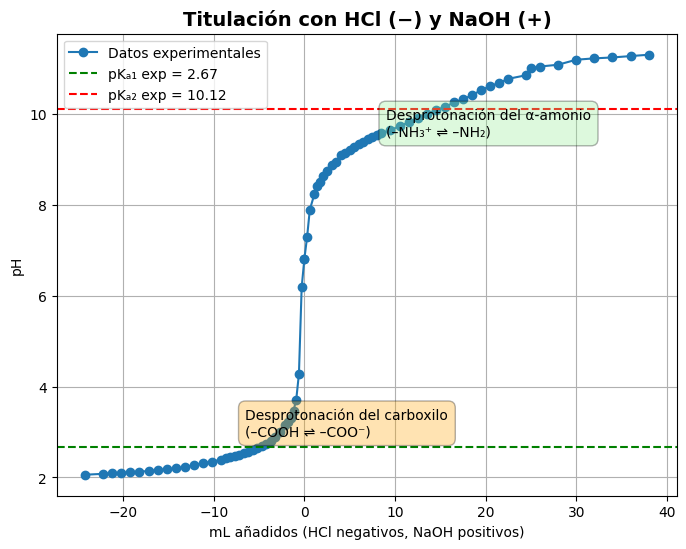

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.6 MB/s eta 0:00:00
✅ Informe_Alanina.pdf generado.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# TITULACIÓN ALANINA: CURVA COMBINADA, pKa/pI, FRACCIONES, PDF
# ============================================================

# 0) Subida de archivos
from google.colab import files
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

print("👉 Selecciona los CSV de HCl y NaOH")
uploaded = files.upload()

df_naoh, df_hcl = None, None
for fname in uploaded.keys():
    low = fname.lower()
    if "naoh" in low:
        df_naoh = pd.read_csv(fname)
        print(f"✔ Cargado NaOH: {fname}")
    elif "hcl" in low:
        df_hcl = pd.read_csv(fname)
        print(f"✔ Cargado HCl: {fname}")

assert df_naoh is not None and df_hcl is not None, "Falta uno de los archivos (NaOH u HCl)."

# 1) Parámetros del ensayo
C_alanina = 0.1      # M
V_alanina_mL = 5.0   # mL
n_alanina_mmol = C_alanina * V_alanina_mL   # 0.5 mmol
C_titulante = 0.05   # M
Veq_teor = n_alanina_mmol / C_titulante     # 10 mL/eq

# 2) Utilidades
def interp_y(x, y, x0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return float(np.interp(x0, x, y))

def err(exp, ref):
    return abs((exp-ref)/ref)*100

# 3) pKa EXPERIMENTALES por medias equivalencias CORRECTAS
#    pKa1: de HCl en 5 mL; pKa2: de NaOH en 15 mL
x_hcl, y_hcl = df_hcl["volumen_mL"].values, df_hcl["pH"].values
x_na,  y_na  = df_naoh["volumen_mL"].values, df_naoh["pH"].values

pKa1_exp = interp_y(x_hcl, y_hcl, 0.5*Veq_teor)             # ~5 mL en HCl
pKa2_exp = interp_y(x_na,  y_na,  Veq_teor + 0.5*Veq_teor)  # ~15 mL en NaOH
pI_exp   = 0.5*(pKa1_exp + pKa2_exp)

# 4) Referencias de literatura (25 °C)
pKa1_ref, pKa2_ref = 2.34, 9.69
pI_ref = 0.5*(pKa1_ref + pKa2_ref)

# 5) Fracciones ionizadas a pH 7 (experimental y referencia)
pH_eval = 7.0

# Carboxilo: HA <-> A-   α_A- = 1/(1+10^(pKa1 - pH))
def frac_A_minus(pH, pKa): return 1/(1+10**(pKa - pH))
# Amonio:   BH+ <-> B    α_BH+ = 1/(1+10^(pH - pKa2))
def frac_BH_plus(pH, pKa): return 1/(1+10**(pH - pKa))

# Con pKa EXPERIMENTALES
carb_Am_exp = frac_A_minus(pH_eval, pKa1_exp)
carb_HA_exp = 1 - carb_Am_exp
ammo_BHp_exp = frac_BH_plus(pH_eval, pKa2_exp)
amina_B_exp  = 1 - ammo_BHp_exp

# Con pKa de LITERATURA
carb_Am_ref = frac_A_minus(pH_eval, pKa1_ref)
carb_HA_ref = 1 - carb_Am_ref
ammo_BHp_ref = frac_BH_plus(pH_eval, pKa2_ref)
amina_B_ref  = 1 - ammo_BHp_ref

# 6) Curva COMBINADA (HCl negativo + NaOH positivo) + líneas en pKa EXPERIMENTALES
df_hcl_adj = df_hcl.copy();  df_hcl_adj["volumen_plot"]  = -df_hcl_adj["volumen_mL"]
df_naoh_adj= df_naoh.copy(); df_naoh_adj["volumen_plot"] =  df_naoh_adj["volumen_mL"]

df_total = pd.concat([df_hcl_adj[["volumen_plot","pH"]],
                      df_naoh_adj[["volumen_plot","pH"]]], ignore_index=True).sort_values("volumen_plot")

plt.figure(figsize=(8,6))
plt.plot(df_total["volumen_plot"], df_total["pH"], "o-", label="Datos experimentales")
plt.axhline(pKa1_exp, color="green", linestyle="--", label=f"pKₐ₁ exp = {pKa1_exp:.2f}")
plt.axhline(pKa2_exp, color="red",   linestyle="--", label=f"pKₐ₂ exp = {pKa2_exp:.2f}")

plt.text(-0.65*Veq_teor, pKa1_exp+0.25,
         "Desprotonación del carboxilo\n(–COOH ⇌ –COO⁻)",
         bbox=dict(facecolor="orange", alpha=0.3, boxstyle="round,pad=0.5"))
plt.text( 0.9*Veq_teor,  pKa2_exp-0.6,
         "Desprotonación del α-amonio\n(–NH₃⁺ ⇌ –NH₂)",
         bbox=dict(facecolor="lightgreen", alpha=0.3, boxstyle="round,pad=0.5"))

plt.title("Titulación con HCl (−) y NaOH (+)", fontsize=14, weight="bold")
plt.xlabel("mL añadidos (HCl negativos, NaOH positivos)")
plt.ylabel("pH")
plt.grid(True); plt.legend()
plt.savefig("curva_combinada.png", bbox_inches="tight"); plt.show()

# 7) Tablas para PDF
tabla_resultados = [
    ["Parámetro", "Experimental", "Literatura", "% Error"],
    ["pKₐ₁", f"{pKa1_exp:.2f}", f"{pKa1_ref:.2f}", f"{err(pKa1_exp,pKa1_ref):.2f}%"],
    ["pKₐ₂", f"{pKa2_exp:.2f}", f"{pKa2_ref:.2f}", f"{err(pKa2_exp,pKa2_ref):.2f}%"],
    ["pI",   f"{pI_exp:.2f}",   f"{pI_ref:.2f}",   f"{err(pI_exp,pI_ref):.2f}%"]
]

tabla_fracciones = [
    ["Grupo / especie", "Experimental", "Literatura"],
    ["Carboxilo A⁻",     f"{carb_Am_exp:.5f}",  f"{carb_Am_ref:.5f}"],
    ["Carboxilo HA",     f"{carb_HA_exp:.5f}",  f"{carb_HA_ref:.5f}"],
    ["Amonio BH⁺",       f"{ammo_BHp_exp:.5f}", f"{ammo_BHp_ref:.5f}"],
    ["Amina libre (B)",  f"{amina_B_exp:.5f}",  f"{amina_B_ref:.5f}"],
]

# 8) PDF (instalar reportlab si falta)
!pip -q install reportlab

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()
doc = SimpleDocTemplate("Informe_Alanina.pdf", pagesize=letter)
story = []

# Portada
story.append(Paragraph("Informe de laboratorio", styles["Title"]))
story.append(Spacer(1,18))
story.append(Paragraph("Carácter anfotérico y punto isoeléctrico de aminoácidos", styles["Title"]))
story.append(Spacer(1,28))
story.append(Paragraph("Muestra: L-alanina 0.1 M (5 mL); Titulantes: HCl/NaOH 0.05 M", styles["Normal"]))
story.append(Spacer(1,12))
story.append(Paragraph("Curva combinada y estimación de pKₐ/pI", styles["Italic"]))
story.append(Spacer(1,24))

# Curva combinada
story.append(Paragraph("Curva de titulación combinada (HCl + NaOH)", styles["Heading2"]))
story.append(RLImage("curva_combinada.png", width=420, height=315))
story.append(Spacer(1,18))

# Resultados vs literatura
story.append(Paragraph("Resultados experimentales vs. literatura", styles["Heading2"]))
t1 = Table(tabla_resultados)
t1.setStyle(TableStyle([
    ("BACKGROUND",(0,0),(-1,0),colors.grey), ("TEXTCOLOR",(0,0),(-1,0),colors.whitesmoke),
    ("ALIGN",(0,0),(-1,-1),"CENTER"), ("GRID",(0,0),(-1,-1),0.5,colors.black),
]))
story.append(t1)
story.append(Spacer(1,18))

# Fracciones ionizadas
story.append(Paragraph(f"Fracciones ionizadas a pH {pH_eval}", styles["Heading2"]))
t2 = Table(tabla_fracciones)
t2.setStyle(TableStyle([
    ("BACKGROUND",(0,0),(-1,0),colors.grey), ("TEXTCOLOR",(0,0),(-1,0),colors.whitesmoke),
    ("ALIGN",(0,0),(-1,-1),"CENTER"), ("GRID",(0,0),(-1,-1),0.5,colors.black),
]))
story.append(t2)
story.append(Spacer(1,18))

# Conclusión breve
story.append(Paragraph("Conclusión", styles["Heading2"]))
story.append(Paragraph(
    "La curva combinada muestra dos regiones tampón correspondientes a los equilibrios del carboxilo (pKₐ₁) y del "
    "grupo α-amonio (pKₐ₂). Los pKₐ experimentales, determinados en las medias equivalencias correctas "
    "(HCl≈5 mL y NaOH≈15 mL), permiten estimar el pI. A pH 7, la alanina está predominantemente en forma zwitteriónica "
    "(–COO⁻ y –NH₃⁺). Las fracciones calculadas con pKₐ experimentales y de literatura concuerdan dentro del error esperado.",
    styles["Normal"]
))
doc.build(story)

print("✅ Informe_Alanina.pdf generado.")

# 9) Descargar
from google.colab import files
files.download("Informe_Alanina.pdf")

👉 Selecciona los CSV de HCl y NaOH


Saving alanina_hcl_datos (1).csv to alanina_hcl_datos (1) (2).csv
Saving alanina_naoh_datos (1).csv to alanina_naoh_datos (1) (2).csv
✔ Cargado HCl: alanina_hcl_datos (1) (2).csv
✔ Cargado NaOH: alanina_naoh_datos (1) (2).csv


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1253: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


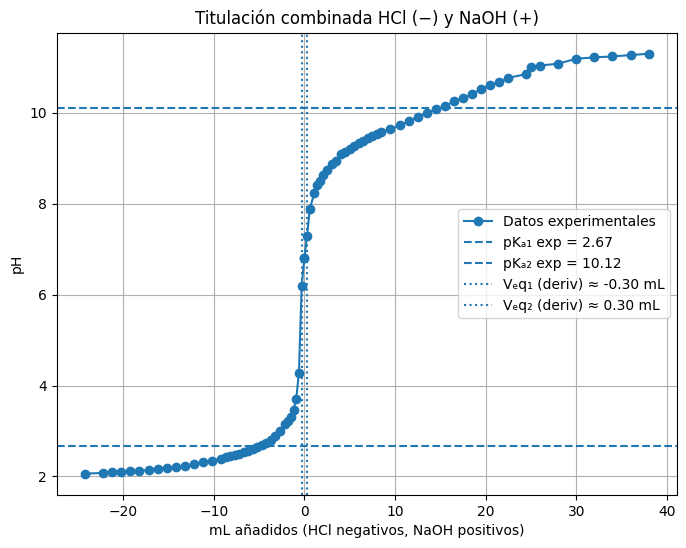

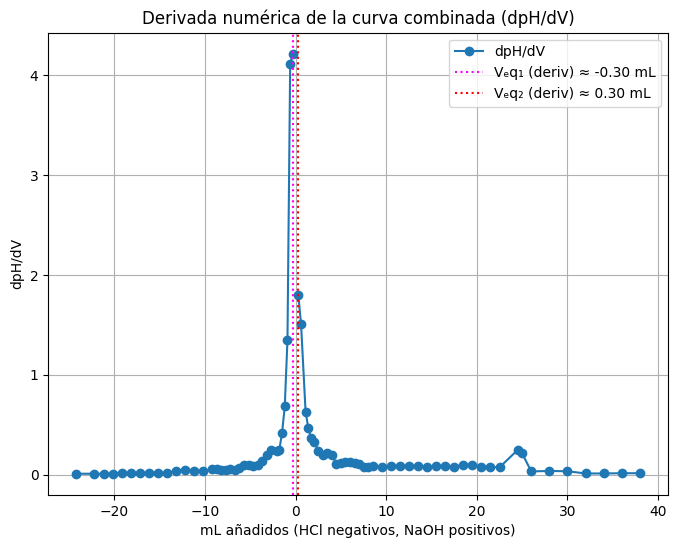

✅ Informe_Alanina.pdf generado.


In [12]:
# ============================================================
# TITULACIÓN ALANINA: CURVA COMBINADA, DERIVADA, pKa/pI, PDF
# ============================================================

# 0) Subida de archivos
from google.colab import files
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

print("👉 Selecciona los CSV de HCl y NaOH")
uploaded = files.upload()

df_naoh, df_hcl = None, None
for fname in uploaded.keys():
    low = fname.lower()
    if "naoh" in low:
        df_naoh = pd.read_csv(fname)
        print(f"✔ Cargado NaOH: {fname}")
    elif "hcl" in low:
        df_hcl = pd.read_csv(fname)
        print(f"✔ Cargado HCl: {fname}")

assert df_naoh is not None and df_hcl is not None, "Falta uno de los archivos (NaOH u HCl)."

# 1) Parámetros del ensayo
C_alanina = 0.1      # M
V_alanina_mL = 5.0   # mL
n_alanina_mmol = C_alanina * V_alanina_mL   # 0.5 mmol
C_titulante = 0.05   # M
Veq_teor = n_alanina_mmol / C_titulante     # 10 mL/eq

# 2) Utilidades
def interp_y(x, y, x0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return float(np.interp(x0, x, y))

def err(exp, ref):
    return abs((exp-ref)/ref)*100

# 3) pKa EXPERIMENTALES por medias equivalencias CORRECTAS
#    pKa1: de HCl en 5 mL; pKa2: de NaOH en 15 mL
x_hcl, y_hcl = df_hcl["volumen_mL"].values, df_hcl["pH"].values
x_na,  y_na  = df_naoh["volumen_mL"].values, df_naoh["pH"].values

pKa1_exp = interp_y(x_hcl, y_hcl, 0.5*Veq_teor)             # ~5 mL (HCl)
pKa2_exp = interp_y(x_na,  y_na,  Veq_teor + 0.5*Veq_teor)  # ~15 mL (NaOH)
pI_exp   = 0.5*(pKa1_exp + pKa2_exp)

# 4) Referencias de literatura (25 °C)
pKa1_ref, pKa2_ref = 2.34, 9.69
pI_ref = 0.5*(pKa1_ref + pKa2_ref)

# 5) Fracciones ionizadas a pH 7 (experimental y referencia)
pH_eval = 7.0
def frac_A_minus(pH, pKa): return 1/(1+10**(pKa - pH))      # Carboxilo: HA <-> A-
def frac_BH_plus(pH, pKa): return 1/(1+10**(pH - pKa))      # Amonio:   BH+ <-> B

# Con pKa EXPERIMENTALES
carb_Am_exp = frac_A_minus(pH_eval, pKa1_exp)
carb_HA_exp = 1 - carb_Am_exp
ammo_BHp_exp = frac_BH_plus(pH_eval, pKa2_exp)
amina_B_exp  = 1 - ammo_BHp_exp

# Con pKa de LITERATURA
carb_Am_ref = frac_A_minus(pH_eval, pKa1_ref)
carb_HA_ref = 1 - carb_Am_ref
ammo_BHp_ref = frac_BH_plus(pH_eval, pKa2_ref)
amina_B_ref  = 1 - ammo_BHp_ref

# 6) Curva COMBINADA (HCl negativo + NaOH positivo)
df_hcl_adj = df_hcl.copy();  df_hcl_adj["volumen_plot"]  = -df_hcl_adj["volumen_mL"]
df_naoh_adj= df_naoh.copy(); df_naoh_adj["volumen_plot"] =  df_naoh_adj["volumen_mL"]

df_total = pd.concat([df_hcl_adj[["volumen_plot","pH"]],
                      df_naoh_adj[["volumen_plot","pH"]]], ignore_index=True).sort_values("volumen_plot")
df_total = df_total.dropna()

# 7) DERIVADA en la curva combinada y estimación de equivalencias
x = df_total["volumen_plot"].values
y = df_total["pH"].values
dydx = np.gradient(y, x)  # derivada numérica dpH/dV

# Encontrar picos "más grandes" a la izquierda (HCl) y derecha (NaOH) de 0 mL
# Tomamos índice del máximo absoluto a cada lado para robustez
left_mask  = x < 0
right_mask = x > 0

if left_mask.any():
    i_left_peak = np.argmax(np.abs(dydx[left_mask]))
    x_left = x[left_mask][i_left_peak]
else:
    x_left = -Veq_teor  # respaldo

if right_mask.any():
    i_right_peak = np.argmax(np.abs(dydx[right_mask]))
    x_right = x[right_mask][i_right_peak]
else:
    x_right = Veq_teor  # respaldo

Veq1_est_comb = x_left    # ~ -10 mL (lado HCl)
Veq2_est_comb = x_right   # ~ +10 mL (lado NaOH)

# Guardar curva combinada
plt.figure(figsize=(8,6))
plt.plot(x, y, "o-", label="Datos experimentales")
plt.axhline(pKa1_exp, linestyle="--", label=f"pKₐ₁ exp = {pKa1_exp:.2f}")
plt.axhline(pKa2_exp, linestyle="--", label=f"pKₐ₂ exp = {pKa2_exp:.2f}")
plt.axvline(Veq1_est_comb, linestyle=":", label=f"Vₑq₁ (deriv) ≈ {Veq1_est_comb:.2f} mL")
plt.axvline(Veq2_est_comb, linestyle=":", label=f"Vₑq₂ (deriv) ≈ {Veq2_est_comb:.2f} mL")
plt.title("Titulación combinada HCl (−) y NaOH (+)")
plt.xlabel("mL añadidos (HCl negativos, NaOH positivos)")
plt.ylabel("pH")
plt.grid(True); plt.legend()
plt.savefig("curva_combinada.png", bbox_inches="tight"); plt.show()

# Guardar derivada
plt.figure(figsize=(8,6))
plt.plot(x, dydx, "o-", label="dpH/dV")
plt.axvline(Veq1_est_comb, linestyle=":", label=f"Vₑq₁ (deriv) ≈ {Veq1_est_comb:.2f} mL", color="magenta")
plt.axvline(Veq2_est_comb, linestyle=":", label=f"Vₑq₂ (deriv) ≈ {Veq2_est_comb:.2f} mL", color="red")
plt.title("Derivada numérica de la curva combinada (dpH/dV)")
plt.xlabel("mL añadidos (HCl negativos, NaOH positivos)")
plt.ylabel("dpH/dV")
plt.grid(True); plt.legend()
plt.savefig("derivada_combinada.png", bbox_inches="tight"); plt.show()

# 8) Tablas para PDF
tabla_resultados = [
    ["Parámetro", "Experimental", "Literatura", "% Error"],
    ["pKₐ₁", f"{pKa1_exp:.2f}", f"{pKa1_ref:.2f}", f"{err(pKa1_exp,pKa1_ref):.2f}%"],
    ["pKₐ₂", f"{pKa2_exp:.2f}", f"{pKa2_ref:.2f}", f"{err(pKa2_exp,pKa2_ref):.2f}%"],
    ["pI",   f"{pI_exp:.2f}",   f"{pI_ref:.2f}",   f"{err(pI_exp,pI_ref):.2f}%"]
]

tabla_fracciones = [
    ["Grupo / especie", "Experimental", "Literatura"],
    ["Carboxilo A⁻",     f"{carb_Am_exp:.5f}",  f"{carb_Am_ref:.5f}"],
    ["Carboxilo HA",     f"{carb_HA_exp:.5f}",  f"{carb_HA_ref:.5f}"],
    ["Amonio BH⁺",       f"{ammo_BHp_exp:.5f}", f"{ammo_BHp_ref:.5f}"],
    ["Amina libre (B)",  f"{amina_B_exp:.5f}",  f"{amina_B_ref:.5f}"],
]

tabla_equivalencias = [
    ["Equivalencia (derivada)", "mL (curva combinada)"],
    ["Vₑq₁ (lado HCl)", f"{Veq1_est_comb:.2f}"],
    ["Vₑq₂ (lado NaOH)", f"{Veq2_est_comb:.2f}"],
]

# 9) PDF (instalar reportlab si falta)
!pip -q install reportlab

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()
doc = SimpleDocTemplate("Informe_Alanina.pdf", pagesize=letter)
story = []

# Portada
story.append(Paragraph("Informe de laboratorio", styles["Title"]))
story.append(Spacer(1,18))
story.append(Paragraph("Carácter anfotérico y punto isoeléctrico de aminoácidos", styles["Title"]))
story.append(Spacer(1,28))
story.append(Paragraph("Muestra: L-alanina 0.1 M (5 mL); Titulantes: HCl/NaOH 0.05 M", styles["Normal"]))
story.append(Spacer(1,12))
story.append(Paragraph("Curva combinada, derivada, pKₐ/pI y fracciones ionizadas", styles["Italic"]))
story.append(Spacer(1,24))

# Curva combinada
story.append(Paragraph("Curva de titulación combinada (HCl + NaOH)", styles["Heading2"]))
story.append(RLImage("curva_combinada.png", width=420, height=315))
story.append(Spacer(1,18))

# Derivada
story.append(Paragraph("Derivada numérica (dpH/dV) de la curva combinada", styles["Heading2"]))
story.append(RLImage("derivada_combinada.png", width=420, height=315))
story.append(Spacer(1,18))

# Resultados vs literatura
story.append(Paragraph("Resultados experimentales vs. literatura", styles["Heading2"]))
t1 = Table(tabla_resultados)
t1.setStyle(TableStyle([
    ("BACKGROUND",(0,0),(-1,0),colors.grey), ("TEXTCOLOR",(0,0),(-1,0),colors.whitesmoke),
    ("ALIGN",(0,0),(-1,-1),"CENTER"), ("GRID",(0,0),(-1,-1),0.5,colors.black),
]))
story.append(t1)
story.append(Spacer(1,18))

# Equivalencias por derivada
story.append(Paragraph("Equivalencias estimadas por derivada", styles["Heading2"]))
t3 = Table(tabla_equivalencias)
t3.setStyle(TableStyle([
    ("BACKGROUND",(0,0),(-1,0),colors.grey), ("TEXTCOLOR",(0,0),(-1,0),colors.whitesmoke),
    ("ALIGN",(0,0),(-1,-1),"CENTER"), ("GRID",(0,0),(-1,-1),0.5,colors.black),
]))
story.append(t3)
story.append(Spacer(1,18))

# Fracciones ionizadas
story.append(Paragraph(f"Fracciones ionizadas a pH {pH_eval}", styles["Heading2"]))
t2 = Table(tabla_fracciones)
t2.setStyle(TableStyle([
    ("BACKGROUND",(0,0),(-1,0),colors.grey), ("TEXTCOLOR",(0,0),(-1,0),colors.whitesmoke),
    ("ALIGN",(0,0),(-1,-1),"CENTER"), ("GRID",(0,0),(-1,-1),0.5,colors.black),
]))
story.append(t2)
story.append(Spacer(1,18))

# Conclusión breve
story.append(Paragraph("Conclusión", styles["Heading2"]))
story.append(Paragraph(
    "La derivada de la curva combinada muestra dos máximos de |dpH/dV| que corresponden a las equivalencias ácida y básica. "
    "A partir de las medias equivalencias correctas se estimaron pKₐ₁ y pKₐ₂ y, por tanto, el pI. "
    "Las fracciones a pH 7 confirman el predominio del zwitterión (–COO⁻ y –NH₃⁺).",
    styles["Normal"]
))
doc.build(story)

print("✅ Informe_Alanina.pdf generado.")




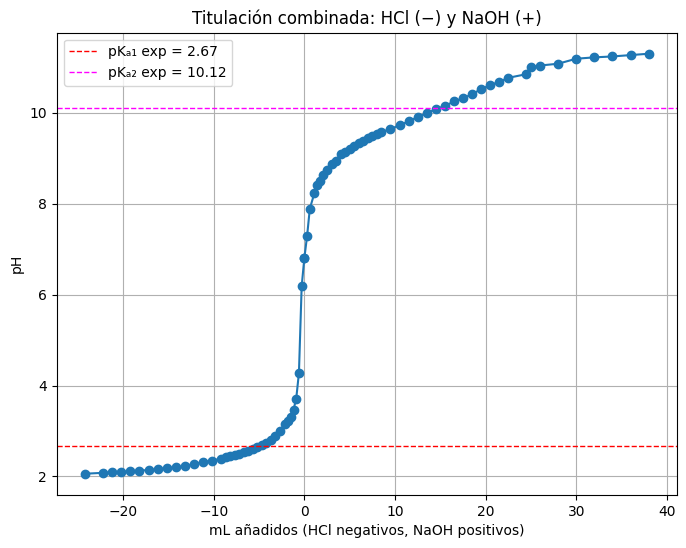

In [10]:
# --- Generar y guardar la curva combinada HCl (−) + NaOH (+) ---
import pandas as pd
import matplotlib.pyplot as plt

# Asume que ya existen df_hcl y df_naoh con columnas: volumen_mL, pH

# 1) HCl hacia la izquierda (volumen negativo), NaOH hacia la derecha (positivo)
df_hcl_adj = df_hcl.copy()
df_hcl_adj["volumen_plot"] = -df_hcl_adj["volumen_mL"]

df_naoh_adj = df_naoh.copy()
df_naoh_adj["volumen_plot"] = df_naoh_adj["volumen_mL"]

# 2) Unir y ordenar
df_total = pd.concat(
    [df_hcl_adj[["volumen_plot","pH"]],
     df_naoh_adj[["volumen_plot","pH"]]],
    ignore_index=True
).sort_values("volumen_plot")

# 3) Graficar y guardar imagen
plt.figure(figsize=(8,6))
plt.plot(df_total["volumen_plot"], df_total["pH"], "o-")
plt.title("Titulación combinada: HCl (−) y NaOH (+)")
plt.xlabel("mL añadidos (HCl negativos, NaOH positivos)")
plt.ylabel("pH")
plt.grid(True)
# Líneas horizontales en pKa experimentales
plt.axhline(pKa1_exp, linestyle="--", linewidth=1, label=f"pKₐ₁ exp = {pKa1_exp:.2f}", color="red")
plt.axhline(pKa2_exp, linestyle="--", linewidth=1, label=f"pKₐ₂ exp = {pKa2_exp:.2f}", color="magenta")
plt.legend()
plt.savefig("curva_combinada.png", bbox_inches="tight")
plt.show()


# La imagen queda guardada como:
# "curva_combinada.png"
